# Time Value of Money And Interest Rate: Finance Fundementals.

In this repository , we will master topics like time value of money concepts: Compounding , discounting , present value, annnuities, and interest rate conventions essentials for quantitative finance.

## 1. Time Value of Money and Interest Rates

A dollar today is worth more that dollar tomorrow. The simple obeservation underpins virutally every financial calculation you will encounter,from pricing bonds and valuing companies to structuring mortgages and retirment plans. The concept is called the **Time Value of Money**(TVM) and understanding it is essential for anyone working in quantitative finance.

Why is money worth more today? Three resasons driven this phenonmenon.

1. Money received today can be invested to ear a return , making it grow over time.

2. Inflation erodes purchasing power so a dollar today buys more than a dollar in the future.

3. There is uncertainity about whether promised future payements will actually materalize. These factors combine to create a fundamentals asymmetry: Present money is more valuable that future money.

The Time value of money gives us a framework for comparing each flows that occur at different points in time. Without this framework, how would you choose between receiving $1,000 today versus $1,100 in one year? Or evaluate a business that requires $1 million upfront but promises $200,000 annually for the next seven years? TVM provides the mathematical machinery to answer these questions rigorously.


Interest rate are the mechanism that links present and future values. They quantify the "price" of borrowing more or the "reward" for lending it. In qunatitative finance, interest rates serve as the foundation for pricing nearly every finance instrument. Understanding how they work , how they compound and how they are quoted across markets is ciritical knowledge.


## 2. Future Value and Compounding

When you deposit money in an interest-bearing account, your balance grows over time. The process by which this occurs and paticularly how interest accumulates on previously earned interest is called compounding.This concept drives both wealth accumulation and debt growth. Let's build up from the simplest case to the continuous limit used in derivatives pricing, understanding each step along the way.

## 4. Simple Interest:

Simple interest is the most basic form of interest calculation and is our conceptual starting point. Under simple interest, the interest accrues only on the original principal amount, never on accumulated interest. Think of it as a linear process: each period adds the same fixed amount of interest, regardless of how much has accumulated before. If you invest a principal 
**P** at an annual interest rate **r** for **t** years, the future value is:

$$ FV = P(1 + r * t)$$

where:
- **FV**: future value of the investment
- **P**: principal amount (initial investment)
- **r**: annual interest rate (expressed as a decimal)
- **t**: time in years

The structure of this formula reveals its linear nature. The term 
**rt** represents the total proportional increase: the rate 
**r** multiplied by time 
**t**. When you add this to 1 (representing the original principal as 100%), you get the total growth factor. Multiplying by 
**P**
**P** then scales this to your actual investment amount. Notice that time and rate enter symmetrically and additively. Doubling the time has exactly the same effect as doubling the rate.

> Simple interest is calculated only on the original principal amount. The interest earned each period remains constant regardless of how long the investment is held.


For example, investing `$1,000` at `5%` simple interest for `3` years yields:



In [1]:
# Simple Interest Calculation
P = 1000
r = 0.05 
t = 3

FV_Simple = P *( 1 + r * t)
print(f"The Future Value :{FV_Simple}")
interest_earned = FV_Simple - P
print(f"Interest earned on the Principal {P} :{interest_earned}")

The Future Value :1150.0
Interest earned on the Principal 1000 :150.0


Lets create a simple Interest function so we can reuse it again:

In [2]:

def SimpleInterest(P,R,T)-> int:
    SimpleInterest = P * ( 1 + R * T)
    return SimpleInterest

Notice that the interest earned ($150) equals the annual interest ($50) multiplied by the number of years (3). Simple interest grows linearly with time, which makes it straightforward to calculate but unrealistic for most financial applications. In the real world, lenders and investors expect to earn interest on their accumulated interest, a concept we turn to next.

## 5. Discrete Comopounding

In Practise, interest typically compounds periodically. This means the interest earned in each perdio is added to the principal and subsequent interest is calculated on this larget balance. The Fundamental insight is that your money earns returns on your original investment and on the returns that investment has already generated.This created exponential rather than linear growth a distinction with profound implications over long time horizons.

To understna why compounding leads to expoential growth, consider what happens period by period. After the first compounding period, your palance is $P(1+r/n)$. After the seond period, interest is calculated on this new, larger balance , giving $P(1+r/n)(1+r/n) = P(1+r/n)^{2}$. Each perdio multiplies the previous balance by the same growth factor, and multiplication repeated many times produces exponential behaviour.

For investment compounding $n$ times per year at annual rate $r$, the future value after $t$ years is :

$$ FV = P ( 1 + r / n)^{nt}$$


where:
- **FV** : future value after 
- **t** :  years
- **P** : principal amount invested
- **r** :  nominal annual interest rate (stated rate)
- **n** : number of compounding periods per year
- **t**: time in years
- $(1+r/n)$: growth factor per compounding period
- $nt$: total number of compounding periods

The formula captures a key insight:each compounding period applies a small growth factor $(1+ r/n)$ , and these compound multiplicatively over *nt* period. The rate per period is *r/n* because we divide the annual rate among *n* periods and total number of periods in *nt* because,we have 
*n* periods per year for *t* years.

More frequent compounding means smaller individual growth factors applies more times, which slightly increases total growth due to the "interest on interest" effect. This is because you begin earning interest on your interest sooner, so you don't have to wait as long for each interest payment to start generating its own returns.

>Compound interest calculates interest on both the initial principal and all previously accumulated interest. This creates exponential growth where earnings accelerate over time.

Lets compare different compounding frequencies for the same nominal rate:



In [3]:
P = 1000
r = 0.05
t = 3


# Different compounding frequencies
compounding = {
    "Annual (n=1)": 1,
    "Semi-annual (n=2)": 2,
    "Quarterly (n=4)": 4,
    "Monthly (n=12)": 12,
    "Daily (n=365)": 365,
}

results = {}
for name, n in compounding.items():
    FV = P * (1 + r / n) ** (n * t)
    results[name] = FV
print(results)

{'Annual (n=1)': 1157.6250000000002, 'Semi-annual (n=2)': 1159.69341821289, 'Quarterly (n=4)': 1160.7545177229981, 'Monthly (n=12)': 1161.4722313334678, 'Daily (n=365)': 1161.8223072263547}


In [6]:
def continous_compounding(P,r,t)-> dict:
    compounding = {
    "Annual (n=1)": 1,
    "Semi-annual (n=2)": 2,
    "Quarterly (n=4)": 4,
    "Monthly (n=12)": 12,
    "Daily (n=365)": 365,
    }

    results = {}
    for name, n in compounding.items():
        FV = P * (1 + r / n) ** (n * t)
        results[name] = FV
    return results

In [10]:
P = 1000
r = 0.05
t = 3
empty_dict = {}
empty_dict = continous_compounding(P,r,t)
print(empty_dict)

{'Annual (n=1)': 1157.6250000000002, 'Semi-annual (n=2)': 1159.69341821289, 'Quarterly (n=4)': 1160.7545177229981, 'Monthly (n=12)': 1161.4722313334678, 'Daily (n=365)': 1161.8223072263547}


As compounding frequency increases, the future value grows, but the incremental gains diminish. Moving from annual to semi-annual compounding adds about $2.07, while moving from monthly to daily adds only about $0.20. This pattern of diminishing returns suggests a natural limit as 
$n→∞$: no matter how frequently you compound, there is an upper bound on the growth you can achieve at a given rate. This limit is not merely a mathematical curiosity; it forms the basis for continuous compounding, the framework preferred in derivatives pricing.


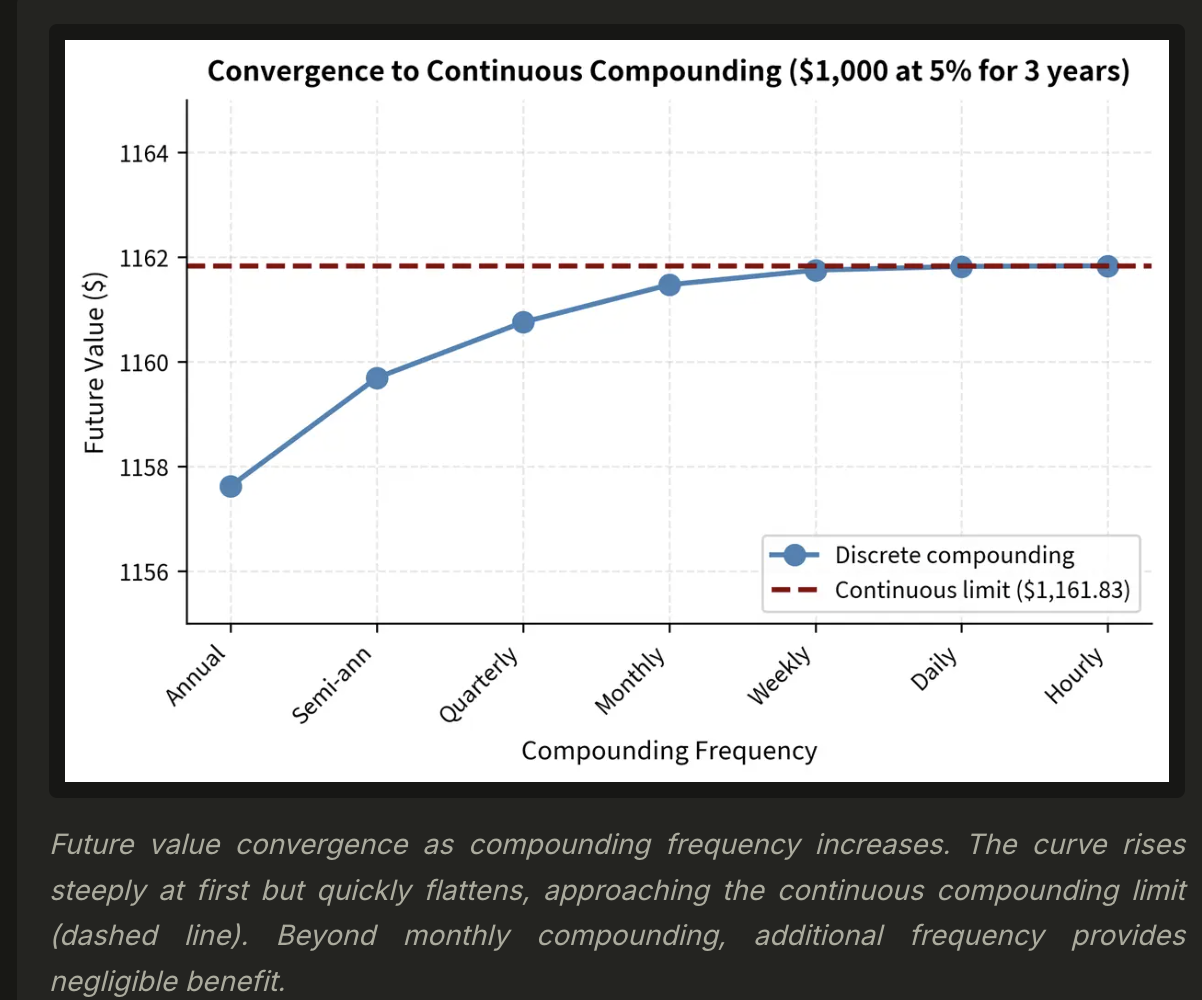



## 6. Continouse Compounding:

Taking the limits as the compounding frequency approaches infinity gives us continous compounding . Rather than compounding at discrete intervals like month , daily or even every second, continous compounding assumes that interest accures and it reinvested at everu instant. This is the standard framework used in derivatives pricing because it simplifies many calculations and produces elegant mathematical properties.

The continous compounding formula emerges from taking the limit of the descrete formula as $n$ grows without bound:

$$\lim_{n -> \infty} P{1 + r / n}^{nt} = P * e ^{rt}$$

where
- **FV**: future value
- **P**: principal amount
- **r**: continuously compounded annual rate
- **t**: time in years
- **e**: Euler's number ( ≈ **2.71828**)
  
This result relies on the fundamental limit , one of the most important limits in mathematics. To see why this limit makes sense intuitively, consider that as $n$ increases, each individual growth factor 
$(1+r/n)$ gets closer to $1$, but you apply more and more of them. These two effects, smaller factors applied more times, balance out to give a finite limit, and that limit happens to be the exponential function.


The exponential function $e^{rt}$ emergers because continous compounding epresents the limiting case of infinitely many infinitesimally small growth events. This makes *continous compounding* mathematically convenient: returns become additive in the logarithm, meaning $ln (FV/P) = rt$. This logarithmic property greatly simplifies many calculations in derivatives pricing, because the return over multiple periods can be computed simply by adding up the returns over sub-periods, rather than multiplying growth factors together.


> Continuous compounding assumes interest accrues and compounds instantaneously at every moment. The future value is calculated as $
FV=Pe^{rt}$ where $e$ is Euler's number.

In [12]:
import numpy as np

## Parameters
P = 1000
r = 0.05
t = 3

#Continous Compounding
FV_Continous = P * np.exp(r * t)

#Compare to discrete compounding
Fv_daily = P * ( 1 + r/ 365) ** (365 * t)
difference = FV_Continous - Fv_daily


print(f"continous_compounding :{FV_Continous}")
print(f"Daily Compounding :{Fv_daily}")
print(f"difference{difference}")

continous_compounding :1161.834242728283
Daily Compounding :1161.8223072263547
difference0.01193550192829207


In [1]:
def discrete_compounding(P,r,t):
    FV_Continous = P * np.exp(r * t)
    Fv_daily = P * ( 1 + r/ 365) ** (365 * t)
    difference = FV_Continous - Fv_daily
    return FV_Continous,Fv_daily,difference

The difference between daily and continuous compounding is negligible for practical purposes. However, continuous compounding has elegant mathematical properties. Returns become additive (the log of a product equals the sum of logs), and many differential equations in finance have cleaner solutions.

Let's visualize how future value grows under different compounding schemes:

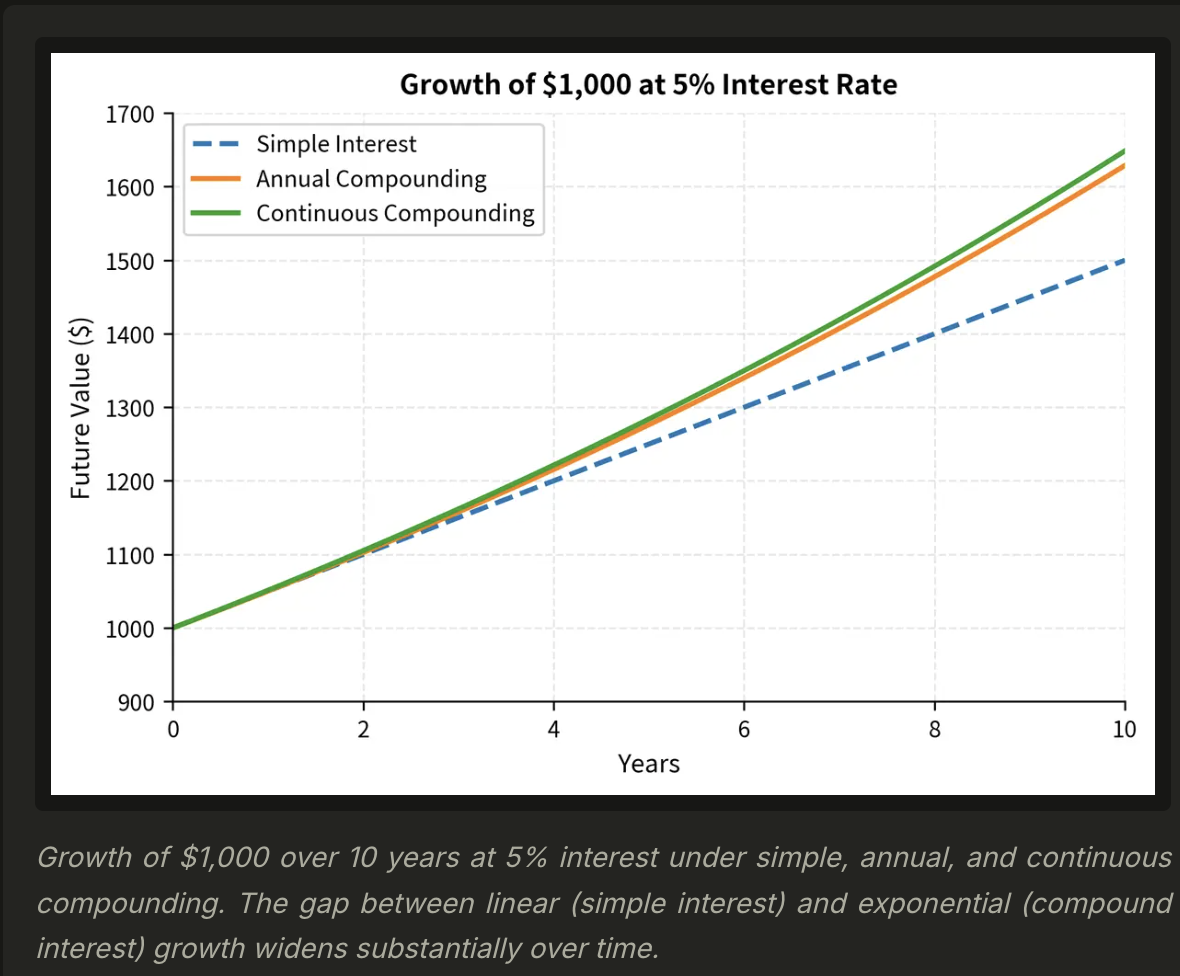

The chart reveals that simple interest grows linearly while compound interest grows exponentially. Over short horizons, the differences are small. Over long horizons, they become dramatic. This explains why compound interest accumulates so powerfully over time.